<a href="https://colab.research.google.com/github/Eyezesco/BigFoot_Sighting_Density_in_the_U.S./blob/main/ToySupply_Chain_Database.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import sqlite3
import pandas as pd
import numpy as np
import os

# Clean up any existing lock file
if os.path.exists('toy_supply.db'):
    os.remove('toy_supply.db')

# 1. Connect to SQLite database
conn = sqlite3.connect('toy_supply.db')
cursor = conn.cursor()

# 2. Create Tables
cursor.execute('''
CREATE TABLE IF NOT EXISTS distribution_centers (
    dc_id INTEGER PRIMARY KEY,
    dc_name TEXT,
    region TEXT,
    max_capacity_units INTEGER
)''')

cursor.execute('''
CREATE TABLE IF NOT EXISTS toy_products (
    product_id INTEGER PRIMARY KEY,
    product_name TEXT,
    category TEXT,
    manufacturing_cost REAL,
    retail_price REAL
)''')

cursor.execute('''
CREATE TABLE IF NOT EXISTS holiday_shipments (
    shipment_id INTEGER PRIMARY KEY,
    product_id INTEGER,
    dc_id INTEGER,
    units_shipped INTEGER,
    transit_days INTEGER,
    is_holiday_surge INTEGER, -- 1 for Q4 peak, 0 for regular season
    stockout_occurred INTEGER, -- 1 for yes, 0 for no
    FOREIGN KEY(product_id) REFERENCES toy_products(product_id),
    FOREIGN KEY(dc_id) REFERENCES distribution_centers(dc_id)
)''')

# 3. Generate Realistic Mock Data
rng = np.random.default_rng(999)

# Insert Distribution Centers
dc_data = [
    (1, 'North American Hub', 'North America', 500000),
    (2, 'European Logistics Center', 'Europe', 350000),
    (3, 'Asia-Pacific Port Hub', 'Asia-Pacific', 600000)
]
cursor.executemany("INSERT INTO distribution_centers VALUES (?, ?, ?, ?)", dc_data)

# Insert Toy Products
categories = ['Action Figures', 'Board Games', 'Educational Tech', 'Plush Toys', 'Outdoor Play']
product_names = [
    'Cyber Robot Action Figure', 'Strategic Conquest Board Game', 'Coding Robot Puppy',
    'Giant Plush Bear', 'Turbo RC Race Car', 'Mini Drone Quadcopter', 'Magnetic Building Tiles',
    'Interactive Escape Room Box', 'Solar System Puzzle Set', 'Electric Scooter'
]

products_data = []
for p_id in range(1, 26):
    name = rng.choice(product_names) + f" (Model-{p_id})"
    cat = rng.choice(categories)
    cost = float(np.round(rng.uniform(5.0, 45.0), 2))
    price = float(np.round(cost * rng.uniform(1.8, 2.6), 2))
    products_data.append((p_id, name, cat, cost, price))

cursor.executemany("INSERT INTO toy_products VALUES (?, ?, ?, ?, ?)", products_data)

# Insert Holiday Shipments
shipments_data = []
for s_id in range(1, 1201):
    p_id = int(rng.integers(1, 26))
    d_id = int(rng.integers(1, 4))
    units = int(rng.integers(500, 15000))
    transit = int(rng.integers(12, 45)) # International shipping transit days
    is_surge = int(rng.choice([0, 1], p=[0.6, 0.4])) # 40% Q4 holiday shipments

    # Surge shipments or long transits have higher stockout risk
    stockout_prob = 0.45 if (is_surge == 1 and transit > 28) else 0.08
    stockout = int(rng.choice([0, 1], p=[1 - stockout_prob, stockout_prob]))

    shipments_data.append((s_id, p_id, d_id, units, transit, is_surge, stockout))

cursor.executemany("INSERT INTO holiday_shipments VALUES (?, ?, ?, ?, ?, ?, ?)", shipments_data)
conn.commit()

# Verify load
df_toy_check = pd.read_sql("SELECT * FROM holiday_shipments LIMIT 5", conn)
print("Toy Supply Chain Database setup complete! Here are your first 5 shipment records:")
display(df_toy_check)


Toy Supply Chain Database setup complete! Here are your first 5 shipment records:


,shipment_id,product_id,dc_id,units_shipped,transit_days,is_holiday_surge,stockout_occurred
0,1,11,2,12743,23,1,0
1,2,17,1,3426,26,1,0
2,3,4,3,8461,19,1,0
3,4,14,3,8092,18,0,0
4,5,5,1,6003,37,0,1


In [ ]:
import sqlite3
import pandas as pd

# Connect to toy supply database
conn = sqlite3.connect('toy_supply.db')

# SQL Query analyzing stockout rates and transit delays during holiday surges vs regular season
toy_query = '''
SELECT
    CASE
        WHEN hs.is_holiday_surge = 1 THEN 'Q4 Holiday Surge'
        ELSE 'Regular Season'
    END AS season_period,
    COUNT(hs.shipment_id) AS total_shipments,
    ROUND(AVG(hs.units_shipped), 0) AS avg_units_shipped,
    ROUND(AVG(hs.transit_days), 1) AS avg_transit_days,
    SUM(hs.stockout_occurred) AS total_stockouts,
    ROUND(SUM(hs.stockout_occurred) * 100.0 / COUNT(hs.shipment_id), 1) AS stockout_rate_pct
FROM holiday_shipments hs
GROUP BY hs.is_holiday_surge
ORDER BY stockout_rate_pct DESC
'''

# Load into DataFrame
df_toy_analysis = pd.read_sql(toy_query, conn)

print("Toy supply chain analysis complete! Here is the holiday demand and stockout breakdown:")
display(df_toy_analysis)

Toy supply chain analysis complete! Here is the holiday demand and stockout breakdown:


,season_period,total_shipments,avg_units_shipped,avg_transit_days,total_stockouts,stockout_rate_pct
0,Q4 Holiday Surge,492,7369.0,28.0,125,25.4
1,Regular Season,708,7785.0,27.1,57,8.1


--- Toy Supply Chain Stockout Summary ---


,season_period,stockout_rate_pct
0,Regular Season,8.1
1,Q4 Holiday Surge,25.4


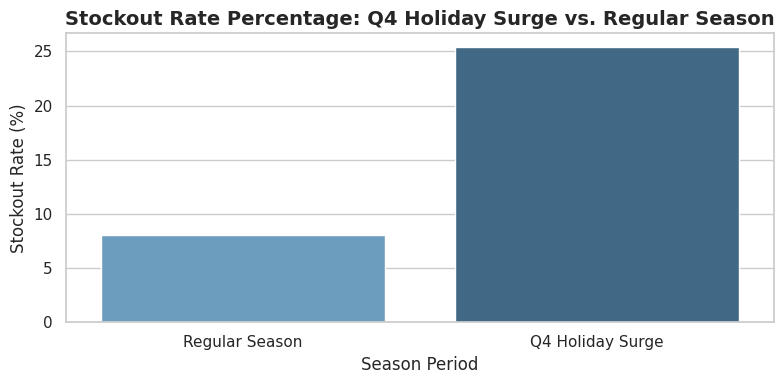

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# SQL Query for stockout percentages to visualize
toy_viz_query = '''
SELECT
    CASE
        WHEN hs.is_holiday_surge = 1 THEN 'Q4 Holiday Surge'
        ELSE 'Regular Season'
    END AS season_period,
    ROUND(SUM(hs.stockout_occurred) * 100.0 / COUNT(hs.shipment_id), 1) AS stockout_rate_pct
FROM holiday_shipments hs
GROUP BY hs.is_holiday_surge
'''
df_toy_viz = pd.read_sql(toy_viz_query, conn)

print("--- Toy Supply Chain Stockout Summary ---")
display(df_toy_viz)

# Visualize Stockout Rate by Season
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 4))

ax = sns.barplot(
    data=df_toy_viz,
    x='season_period',
    y='stockout_rate_pct',
    palette='Blues_d',
    hue='season_period',
    legend=False
)

plt.title('Stockout Rate Percentage: Q4 Holiday Surge vs. Regular Season', fontsize=14, fontweight='bold')
plt.xlabel('Season Period', fontsize=12)
plt.ylabel('Stockout Rate (%)', fontsize=12)
plt.tight_layout()

plt.show()